<a href="https://colab.research.google.com/github/schmitfe/Nawrot_CNS_Course/blob/main/Decoding_Motor_Cortex_Activity_Part_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decoding of Movement Direction from Single Unit Activity in the Monkey Motor Cortex

# Part I – Time-resolved directional tuning in single neurons

Latest update: June, 2024

**Martin Nawrot and Alexa Riehle**

Computational Systems Neuroscience and Animal Physiology, Institute for Zoology, Department of Biology, University of Cologne, D 50674 Cologne.

Institut de Neurosciences Cognitives de la Méditerranée, Centre National de la Recherche Scientifique (CNRS) and University of Aix-Marseille, F 13402 Marseille

## Synopsis

This course module introduces the student to the analysis of directional tuning in single unit recordings from the motor cortex of the behaving monkey. Goal of this module is to exercise the analysis of single-unit spike train data, to rehearse basic concepts of neuronal tuning curves and rate coding. The students will analyze the directional information present in single unit activity recorded from the monkey primary motor cortex during the preparation and execution of center-out arm reaching movements. The first part focuses on computing the classical ('static') directional tuning from the average firing rate during the movement execution phase. The second part investigates the dynamics of movement encoding using the time- resolved estimation of tuning measures during the experimental phase of movement preparation. This teaching module addresses master and graduate students from both, experimental and theoretical background. This module is designed for one course day including an introductory lecture, practical course work, and final presentation of results. The experiment and the data have been described in detail in a recent publication [1].

## Supplemental Material

With this course module we provide additional data files for practical analysis. Data courtesy: *Alexa Riehle, Mediterranean Institute of Cognitive Neuroscience – Centre National de la Recherche Scientifique (CNRS) and University of Aix-Marseille, 13402 Marseille, France.*


## Introduction

In the early and mid 1980's Georgopoulus and coworkers showed that a large proportion of neurons in the primary motor cortex of the behaving monkey show a dependence of their firing probability on the direction of an arm movement [2]. This was studied in an experimental paradigm known as the 'center-out task' where the monkey has to perform arm movements from a central starting position (center) to one out of several targets which are arranged on an outer circle (out) around the central starting position. In the present exercises, you will analyze single unit recordings from the primary motor cortex (M1) of one monkey (monkey 1 in [1,7,8]), which performed a delayed center-out task. The experiments were carried out in the lab of Alexa Riehle. The task and the data are described in detail in [1]. Additional analyses on the trial-to-trial variability of the same data set is shown in [8]. For an introduction to directional tuning in the motor cortex refer to text books on neurophysiology. An in-depth coverage is found in [3].

## Data Sets

All motor-cortex data used in this course are stored inside `data/motor_cortex/` in this repository. In Colab, run the setup cell below once; it clones the repository and defines `DATA_DIR`, `SPARSE_DATA_DIR`, `SELECTED_C1_DIR`, and `SELECTED_C3_DIR`.

The files are Matlab `.mat` files. In Python, a robust loading pattern is:

```python
from scipy.io import loadmat
mat = loadmat(path, squeeze_me=True, struct_as_record=False)
sparse_format = mat["SparseFormat"]
spike_matrices = sparse_format.Data
time_resolution_ms = sparse_format.TimeResolutionMS
cut_interval_ms = sparse_format.CutIntervalMS
```

`spike_matrices` is a length-6 NumPy array. Each entry corresponds to one movement direction and is stored as a sparse matrix with shape `(time_bins, n_trials)`. Convert a sparse matrix to a dense NumPy array with `.toarray()` when needed.


In [ ]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/schmitfe/Nawrot_CNS_Course.git"
REPO_NAME = "Nawrot_CNS_Course"


def prepare_repo() -> Path:
    if "google.colab" in sys.modules:
        repo_root = Path("/content") / REPO_NAME
        if not repo_root.exists():
            subprocess.run(["git", "clone", REPO_URL, str(repo_root)], check=True)
        os.chdir(repo_root)
        return repo_root.resolve()
    return Path.cwd().resolve()


REPO_ROOT = prepare_repo()
DATA_DIR = REPO_ROOT / "data" / "motor_cortex"
SPARSE_DATA_DIR = DATA_DIR / "data_sparse_FromLinux"
SELECTED_C1_DIR = DATA_DIR / "SelectedDataC1"
SELECTED_C3_DIR = DATA_DIR / "SelectedDataC3"

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DATA_DIR = {DATA_DIR}")



## 1. Directional tuning curves of single units

In this first part the goal is (1) to estimate the so-called single neuron tuning curves, i.e. the mean firing rate in relation to the direction of the arm movement, (2) to measure the signal- to-noise ratio of the direction signal, and (3) to present the results in an appropriate figure. To measure the classical tuning curve we align the data to the time of movement onset (MO). This trigger time was detected during the experiment as the point in time when the monkey's hand left the central resting position (cf. Materials and Methods in [1]). The respective data files contain “MO” in their filename and each contains the spike data from 1000 ms before to 1000 ms after MO. The classical tuning curve measures the trial-averaged firing rate for each direction during a certain time epoch around MO.

**Tasks**

1.1. Choose one single data file and load it into memory. For example, you can start with a file from `SPARSE_DATA_DIR` or with one of the smaller teaching subsets in `SELECTED_C1_DIR` or `SELECTED_C3_DIR`.


1.2. The spike data are stored as sparse matrices for efficient memory usage. Define a variable that stores the spike trains of all 6 movement directions.
*Tip*: In Python, `.toarray()` is usually more convenient than `.todense()` because it returns a standard NumPy array.


1.3. Explore the spike train data by taking out one set of trials (e.g. for direction 1) and generate a raster plot (dot-display) using the proper time axis. Remember that for data that was cut relative to the temporal trigger MO, the index 1 in the first dimension (time) refers to the time point t=-1000 ms *before* movement onset. How can you make sure that the time points are plotted relative to MO at t=0?

1.4.  Generate the Peri-Stimulus-Time Histogram (PSTH) for all six directions using a defined array of histogram bin edges. Compute the counts explicitly with `np.histogram` and visualize the result with `plt.stairs` or `ax.bar` so that the relation between bin edges and spike counts stays transparent.

1.5. Plot the outlines of the 6 different PSTHs into one figure. You may use the `stairs` command to do this. How does the PSTH look like? At a first glance, do the PSTHs look different for different directions?

1.6.  Choose a useful time interval around movement onset (MO) to compute tuning strength. Count the number of spikes within this time interval for each direction and each trial. Divide this number by the length of the time interval (in seconds) to obtain the firing rate. Generate a plot of the tuning curve where for each direction (1-6 on the x-axes) the trial-averaged firing rate is plotted on the y-axis. Add to this plot the individual trial rates to represent the trial-by-trial variability (cf. example figures in the appendix). Does the mean rate vary with direction? Does it vary strongly when taking into account the variations across trials?

1.7. Plot directional tuning in a vector plot using the argument ```projection='polar'```, have a look at [polar plot](https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_demo.html). Now compute the vector sum from all 6 directions and add this to the graph in a different color. This vector points into the preferred direction of this particular neuron. What is the preferred direction in degrees? Note: You have for each direction the length of the vector given by the average rate. You can define the vector angle in radians (direction 1 is defined as 0 rad – between neighbouring directions there are 60 degrees or $1/6 \cdot 2π$ in radians), and then translate to Euclidian coordinates.

1.8. To quantify the strength of tuning calculate the signal to noise ratio SNR (explained in supplement of [4] and in [5]. It is defined as the ratio of the signal variance (cf. Lecture) and the noise variance. It expresses how strong the spike rate varies across direction (signal) in relation to how strong the spike rate varies across trials (noise).
Note: The variance of the signal is simply the variance of the trial-averaged firing rates for the 6 directions. Write your own function for computing the SNR: To calculate the noise variance, first subtract the trial averaged rate from the single trial rates for each direction separately. Then compute the variance of the resulting numbers pooled from all 6 directions. Note, that this direct measure of the SNR is biased towards higher values (see Lecture), i.e. we overestimate the true values.

1.9. Compare results of SNR, tuning vector length, and preferred direction with other example neurons that had been chosen by your class mates.

1.10. *Optional*: If you were fast, write a script that loops across all data files to compute the SNR for all neurons. Compute the histogram from all SNRs in a new Figure 1x. As a rule of thumb, only neurons with SNR ≥ 1 show a 'significant' tuning that could be reliably used e.g. for real-time decoding purposes. However, extracting simultaneously the information from many weakly tuned neurons might still result in a reasonable decoding power (population decoding, e.g.[1]).

1.11. *Optional*: If you were really fast you can test for significant SNR. To do so you can shuffle trials across directions to construct a surrogate data set and then compute the SNR from this randomized data set. Repeat this procedure at least 100 times. This results in 100 or more SNR values for surrogate data. Now compare your original SNR value of the non-shuffled data set. Does this value lie within the 5% upper quantile of the surrogate distribution?

## 2 *(Optional)*. Time-resolved measures of tuning for single units  
This second part investigates the dynamic properties of directional tuning in single units. To this end we use the time resolved average firing rate as measured for each of the six directions using kernel convolution and produce a color-coded visualization of the temporal and directional dependence of activity. Again, the SNR – now as a function of time – will serve as a one-dimensional quantity of the tuning strength, while the time resolved preferred direction shows constancy or rotation of the tuning vector. You should compose Figure 2 that displays all three time-resolved measures in three subplots that share the same time axes.

**Tasks**

2.1. Choose a dataset (one particular unit) where spike times are aligned to movement onset (MO). For each of the six directions separately, estimate the time-resolved firing rate for all trials using kernel convolution [6].

  a. For each direction, start from the full binary 2D spike matrix with shape `(time_bins, n_trials)`. We call this matrix `S`.
  
  b. Construct the kernel function as a 1D array of length `w`. The simplest choice is a boxcar kernel, i.e. `k(t) = c` within a finite window of width `w`. The width `w` sets the time resolution of the rate estimate. Normalize the kernel to unit area while taking the time resolution of the data into account. Plot the kernel in a separate figure as a sanity check.
  
  c. For each direction, estimate all single-trial rate functions. You may convolve the full spike matrix at once by using `scipy.signal.lfilter(..., axis=0)`, or you may use `np.convolve` in a loop, or `scipy.signal.convolve2d` with an explicit row vector kernel.


2.2. Construct a matrix with the trial-averaged rate function for each direction. Use `imshow()` to produce a color-coded display of the matrix in the top panel of Figure 2. Define the time axis explicitly from `cut_interval_ms` so the horizontal axis is labeled in milliseconds relative to movement onset. `colorbar()` creates a second axis with the color scale; if needed, adjust the axes layout afterward so the data panel keeps a readable aspect ratio.


2.3. *Optional*: If you were fast, try out the interpolation of the discrete values across directions. To do this first construct a (time x 8) matrix, where the $6_{th}$ direction is represented in the first column and the $1^{st}$ direction is represented in the $2^{nd}$ but also again in the $8^{th}$ column to allow for a "wrap around" effect when interpolating. Have a look at the functions in  `scipy.interpolate` for interpolation.

2.4. Measure the time resolved signal-to-noise ratio SNR (see part 1), i.e. measure the SNR for each time step on the basis of the time-resolved single trial rate estimates. Plot the SNR as a function of time in the second panel of Figure 2. If you wish, you may estimate and plot the time-resolved SNR for different single units and plot them in different colors.

2.5. *Optional*: You may also try out other measures of tuning strength as e.g. described in the methods section of [1] and displayed in Fig. 3A of [1].

2.6. Compute the preferred direction (see part 1) for each time step on the basis of the trial- averaged firing rates and plot it as a function of time in the third panel of Figure 2. Do you observe strong changes in the preferred direction? If so, do they occur during instances where the tuning was strong or during instances where the tuning is weak? Check whether all axes have been labeled correctly. Is the time axis identical for all three subplots?

2.7. Compare results for different single neurons with your class mates. How does the time- resolved tuning compare across different experimental conditions (e.g. C1 vs C3)?

firing rates variance of signal / variance of the Noise
1. for each direction get the mean
2. for each direction substract the mean from each trial to get the noise

## References

[1] Rickert J, Riehle A, Aertsen A, Rotter S, Nawrot MP (2009) Dynamic encoding of movement direction in motor cortical neurons. Journal of Neuroscience 29: 13870-13882

[2] Georgopoulos et al. (1982) On the relations between the direction of two-dimensional arm movements and cell discharge in primate motor cortex. J Neurosci 2(11): 1527-37

[3] Motor Cortex in Voluntary Movements: a distributed system for distributed functions (2005) Alexa Riehle, Eilon Vaadia (Eds.) CRC Press, Boca Raton, Florida, USA

[4] Mehring et al. (2003) Inference of hand movements from local field potentials in monkey motor cortex. Nat Neurosci 6(12): 1253-54

[5] Strube-Bloss MF, Nawrot MP, Menzel R (2011) Mushroom body output neurons encode odor-reward associations. The Journal of Neuroscience 31: 3129–3140.

[6] Nawrot M, Aertsen A, Rotter S (1999) Single-trial estimation of neuronal firing rates - From single neuron spike trains to population activity. J Neurosci Meth 94: 81-92


[7] Bastian, A., Schoner, G., and Riehle, A. (2003). Preshaping and continuous evolution of motor cortical representations during movement preparation. European Journal of Neuroscience, 18(7):2047–2058

[8] Nawrot MP (2010) Analysis and interpretation of interval and count variability in neural spikes trains. In: Grün S, Rotter S (eds) Analysis of parallel spikes trains. Springer Series in Computational Neuroscience 7. Springer Verlag, New York, Berlin, pp 34-58


[9] Lungu IA, Riehle A, Nawrot MP*, Schmuker M* (2017) Predicting voluntary movements, from motor cortical activity, with neuromorphic hardware, IBM Journal of Research & Development 61 (2-3): 5


##Appendix:
Example plots.

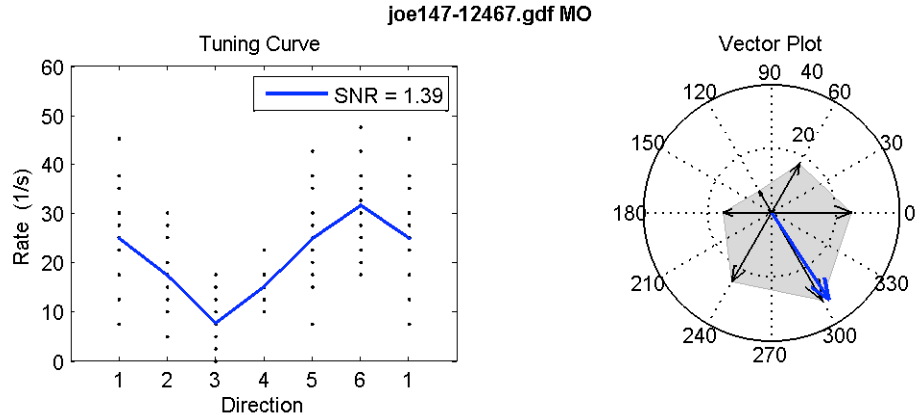

**Example figure 1. Tuning measures for one single unit.** Left: Single trial firing rates for directions 1
to 6 and average firing rates (blue line, tuning curve). Signal-to-noise ratio (SNR) as indicated. Right:
Tuning vector (blue) results as vector sum from the individual direction vectors (black). The length of
each direction vector equals the average firing rate for this direction. The time interval for rate
estimation was chosen as T = (800ms, 1200ms].

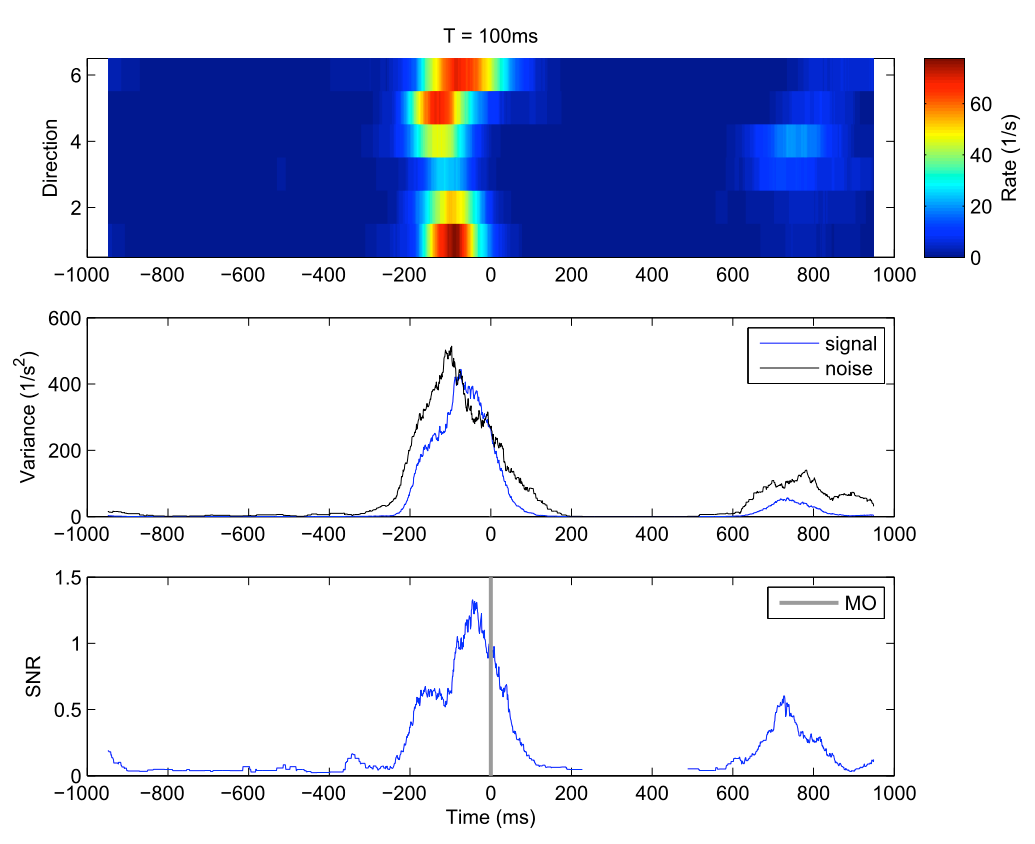

**Example figure 2. Time resolved tuning analysis.** Top: Color coded trial-averaged rate functions for
all 6 directions estimated with a boxcar kernel (moving window) of width 100ms. Middle: Signal
(Variance across the six trial-averaged firing rates) and noise (Variance across trials after subtraction
of mean firing rates). Bottom: Trial-averaged signal-to-noise ratio (SNR) estimated from firing rates
estimated with a boxcar kernel of width 100ms.